In [1]:
import ta_functions as ta
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
TICKERS = ["TSLA", "NVDA", "COIN", "SHOP", "NKE", "SMCI", "XPEV", "NIO", "GOOGL", "AAPL", "UNH", "XYZ"]
YEARS_OF_DATA = 2
PROFIT_TARGET = 0.05
STOP_LOSS = 0.03
FORWARD_DAYS = 14

# Time window
end_date = datetime.now()
start_date = end_date - timedelta(days=365 * YEARS_OF_DATA)

# Shared model components
FEATURES = ['RSI', 'SMA1', 'SMA2', 'SMA3', 'MACD', 'Signal_Line',
            'Upper_Band', 'Lower_Band', 'Volume_MA20',
            '5_day_return', '10_day_return', 'Volatility',
            'CCI', 'OBV', '+DI', '-DI', 'ADX', 'ATR', 
            'VWMA', 'VI+','VI+', 'KCu','KCl', 'STu', 'STl']

results = []


In [3]:
# Functions
def get_stock_data(ticker, start_date, end_date):
    #print("Getting data for:   ", ticker)
    df = yf.download(ticker, start=start_date, end=end_date + timedelta(days=1), 
                     interval='1d', auto_adjust=False, progress=False)
    df = df.reset_index()
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
    return df

def add_technical_indicators(df):
    df['SMA1'] = df['Close'].rolling(window=14).mean()
    df['SMA2'] = df['Close'].rolling(window=20).mean()
    df['SMA3'] = df['Close'].rolling(window=50).mean()
    df['RSI']= ta.calculate_rsi(df)
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['Upper_Band'] = df['SMA1'] + (2 * df['Close'].rolling(20).std())
    df['Lower_Band'] = df['SMA1'] - (2 * df['Close'].rolling(20).std())
    df['Volume_MA20'] = df['Volume'].rolling(window=20).mean()
    df['CCI'] = ta.calculate_cci(df)
    df['OBV'] = ta.calculate_obv(df)
    df[['+DI', '-DI', 'ADX']] = ta.calculate_dmi(df, n=14)
    df['ATR'] = ta.calculate_atr(high=df.High, low=df.Low, close=df.Close)
    
    df['VWMA'] = ta.calculate_vwma(df)
    df[['KCm', 'KCu', 'KCl']] = ta.calculate_keltner(df)
    df[['VI+', 'VI-']] = ta.calculate_vortex(df)
    df[['STu', 'STl']] = ta.calculate_supertrend(df)

    return df

def compute_expected_return(df):
    df['5_day_return'] = df['Close'].pct_change(int(FORWARD_DAYS/2))
    df['10_day_return'] = df['Close'].pct_change(FORWARD_DAYS)
    df['Volatility'] = df['Close'].rolling(FORWARD_DAYS).std()
    df['Expected_Return'] = np.nan
    close_prices = df['Close'].values
    for i in range(len(close_prices) - FORWARD_DAYS):
        current_price = close_prices[i]
        future_max = np.nanmax(close_prices[i + 1:i + 1 + FORWARD_DAYS])
        expected_return = (future_max - current_price) / current_price
        df.iloc[i, df.columns.get_loc('Expected_Return')] = expected_return
    return df

def compute_expected_loss(df):
    df['Expected_Loss'] = np.nan
    close_prices = df['Close'].values
    for i in range(len(close_prices) - FORWARD_DAYS):
        current_price = close_prices[i]
        future_min = np.nanmin(close_prices[i + 1:i + 1 + FORWARD_DAYS])
        expected_loss = (future_min - current_price) / current_price
        df.iloc[i, df.columns.get_loc('Expected_Loss')] = expected_loss
    return df

def add_lagged_features(df, lags=[1, 2, 3]):
    for lag in lags:
        for feature in FEATURES:
            if feature in df.columns:
                df[f"{feature}_lag{lag}"] = df[feature].shift(lag)
    return df

### Improvements

Handles randomforests well - check prediction after

In [4]:
# Core features
for ticker in TICKERS:
    try:
        df = get_stock_data(ticker, start_date, end_date)
        df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')
        df = add_technical_indicators(df)
        df = compute_expected_return(df)
        df = compute_expected_loss(df)  # Add loss calculation
        
        df_model = df.dropna(subset=FEATURES + ['Expected_Return', 'Expected_Loss'])
        
        if len(df_model) < 50:
            continue

        # Train return model
        X = df_model[FEATURES]
        y_return = df_model['Expected_Return']
        scaler_return = StandardScaler()
        X_scaled_return = scaler_return.fit_transform(X)
        model_return = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        model_return.fit(X_scaled_return, y_return)

        # Train loss model
        y_loss = df_model['Expected_Loss']
        scaler_loss = StandardScaler()
        X_scaled_loss = scaler_loss.fit_transform(X)
        model_loss = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        model_loss.fit(X_scaled_loss, y_loss)

        latest = df.iloc[[-1]]
        if latest[FEATURES].isnull().values.any():
            continue
            
        # Predict both return and loss
        latest_scaled_return = scaler_return.transform(latest[FEATURES])
        latest_scaled_loss = scaler_loss.transform(latest[FEATURES])
        predicted_return = model_return.predict(latest_scaled_return)[0]
        predicted_loss = model_loss.predict(latest_scaled_loss)[0]

        entry_price = latest['Close'].values[0]
        predicted_tp = entry_price * (1 + predicted_return)
        predicted_sl = entry_price * (1 + predicted_loss)  # Using predicted loss for SL
        optimal_entry = (predicted_sl + entry_price) / 2  # Average of predicted SL and TP
        entry_discount_pct = ((optimal_entry-entry_price) / entry_price) * 100

        results.append({
            "Ticker": ticker,
            "Date": latest.index[-1].date(),
            "Price": round(entry_price, 2),
            "Max (%)": round(predicted_return * 100, 2),
            "Max (TP)": round(predicted_tp, 2),
            "Loss (%)": round(predicted_loss * 100, 2),
            "SL": round(predicted_sl, 2),  # Now using predicted SL
            "TP": round(predicted_tp, 2),  # Now using predicted TP
            "Entry": round(optimal_entry, 2),
            "Entry%": round(entry_discount_pct, 2),
            "Signal": "✅ Good Value" if entry_discount_pct > 1 else "⚠️ Overvalued",
            "Risk": "⚠️ High Risk" if abs(predicted_loss) > STOP_LOSS else "🟢 Low Risk"
        })

    except Exception as e:
        print(f"Error processing {ticker}: {e}")


# Display results
df_results = pd.DataFrame(results)
print("\n=== Multi-Ticker Prediction Table (Modified) ===")
print(tabulate(df_results, headers='keys', tablefmt='plain'))


=== Multi-Ticker Prediction Table (Modified) ===
    Ticker    Date          Price    Max (%)    Max (TP)    Loss (%)      SL      TP    Entry    Entry%  Signal         Risk
 0  TSLA      2025-06-13   325.31      11.38      362.34       -5.03  308.93  362.34   317.12     -2.52  ⚠️ Overvalued  ⚠️ High Risk
 1  NVDA      2025-06-13   141.97       5.63      149.96       -6.03  133.41  149.96   137.69     -3.01  ⚠️ Overvalued  ⚠️ High Risk
 2  COIN      2025-06-13   242.71       6.44      258.34      -10.73  216.67  258.34   229.69     -5.36  ⚠️ Overvalued  ⚠️ High Risk
 3  SHOP      2025-06-13   105.34       4.93      110.53       -4.16  100.96  110.53   103.15     -2.08  ⚠️ Overvalued  ⚠️ High Risk
 4  NKE       2025-06-13    60.53       7.01       64.77       -4.96   57.53   64.77    59.03     -2.48  ⚠️ Overvalued  ⚠️ High Risk
 5  SMCI      2025-06-13    41.56       3.86       43.17      -26.39   30.59   43.17    36.08    -13.2   ⚠️ Overvalued  ⚠️ High Risk
 6  XPEV      2025-06-13   

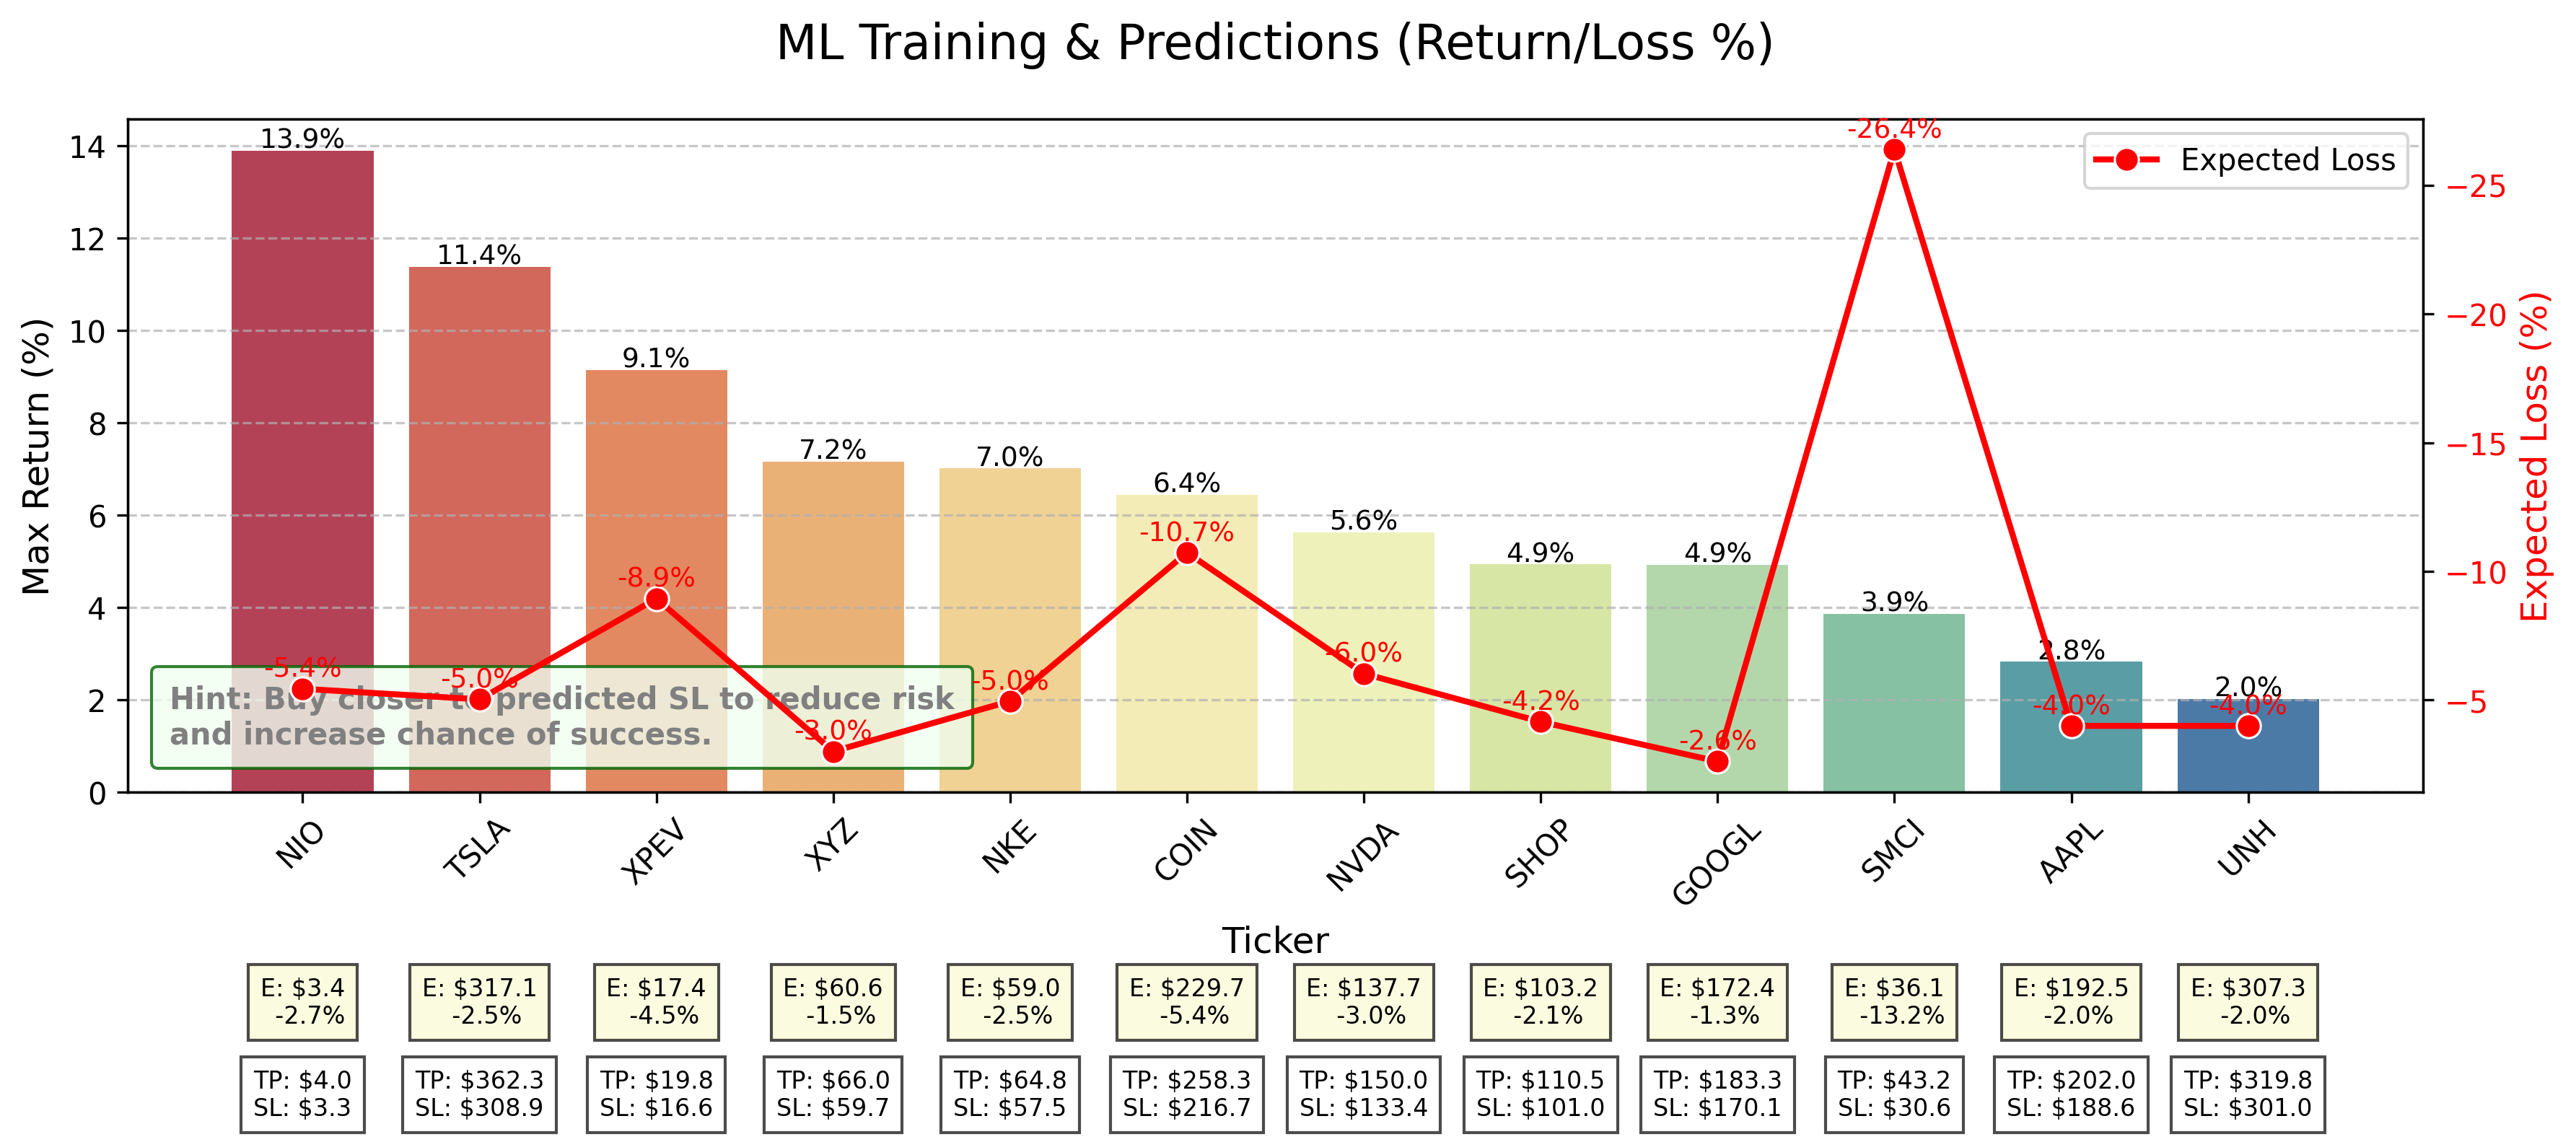

In [5]:
# ✅ PLOTTING ONLY
from matplotlib.offsetbox import AnchoredText

df_plot = df_results.sort_values(by="Max (%)", ascending=False)

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=300)

# Plot Max (%) on primary axis (left)
sns.barplot(x="Ticker", y="Max (%)", data=df_plot, palette="Spectral", ax=ax1)
ax1.set_ylabel('Max Return (%)', fontsize=12)
ax1.set_xlabel('Ticker', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Create secondary axis (right) for Loss (%)
ax2 = ax1.twinx()
sns.lineplot(x="Ticker", y="Loss (%)", data=df_plot, color='red', marker='o', ax=ax2, linewidth=2, markersize=8, label='Expected Loss')
ax2.set_ylabel('Expected Loss (%)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.invert_yaxis() 

# Annotate TP and SL values
for i, (_, row) in enumerate(df_plot.iterrows()):   
     # Annotate Max (%)
    ax1.text(i, row["Max (%)"] + 0.5, f'{row["Max (%)"]:.1f}%', ha='center', va='top', fontsize=9)
    
    # Annotate Loss (%)
    ax2.text(i, row["Loss (%)"] - 1.25, f'{row["Loss (%)"]:.1f}%', ha='center', va='top', color='red', fontsize=9)

    ax1.text(i, -4, f'E: ${row["Entry"]:.1f}\n  {row["Entry%"]:.1f}%',
            ha='center', va='top', fontsize=8, 
            bbox=dict(facecolor='lightgoldenrodyellow', alpha=0.7))
    
    # Annotate TP and SL prices below bars
    ax1.text(i, -6, f'TP: ${row["Max (TP)"]:.1f}\nSL: ${row["SL"]:.1f}', 
             ha='center', va='top', fontsize=8, bbox=dict(facecolor='white', alpha=0.7))

# Add the strategic hint textbox
textbox = AnchoredText(
    "Hint: Buy closer to predicted SL to reduce risk\nand increase chance of success.",
    loc='lower left',
    frameon=True,
    borderpad=1,
    prop=dict(size=10, color='gray', weight='bold')
)
ax1.add_artist(textbox)

# Customize the textbox appearance
textbox.patch.set_facecolor('honeydew')  # Light green background
textbox.patch.set_edgecolor('darkgreen')  # Dark green border
textbox.patch.set_alpha(0.8)             # Slight transparency
textbox.patch.set_boxstyle("round,pad=0.2")  # Rounded corners

plt.title("ML Training & Predictions (Return/Loss %)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()


=== Backtest Statistics ===
Period: 2024-06-12 to 2025-06-13
Total Trades: 21
Wins#: 15.00
Failures: 6.00
Win Rate: 71.4%
Avg Return: 5.63%
Median Return: 5.33%
Max Gain: 32.07%
Max Loss: -7.14%
Return/Risk Ratio: 0.79
Profit Factor: 5.14


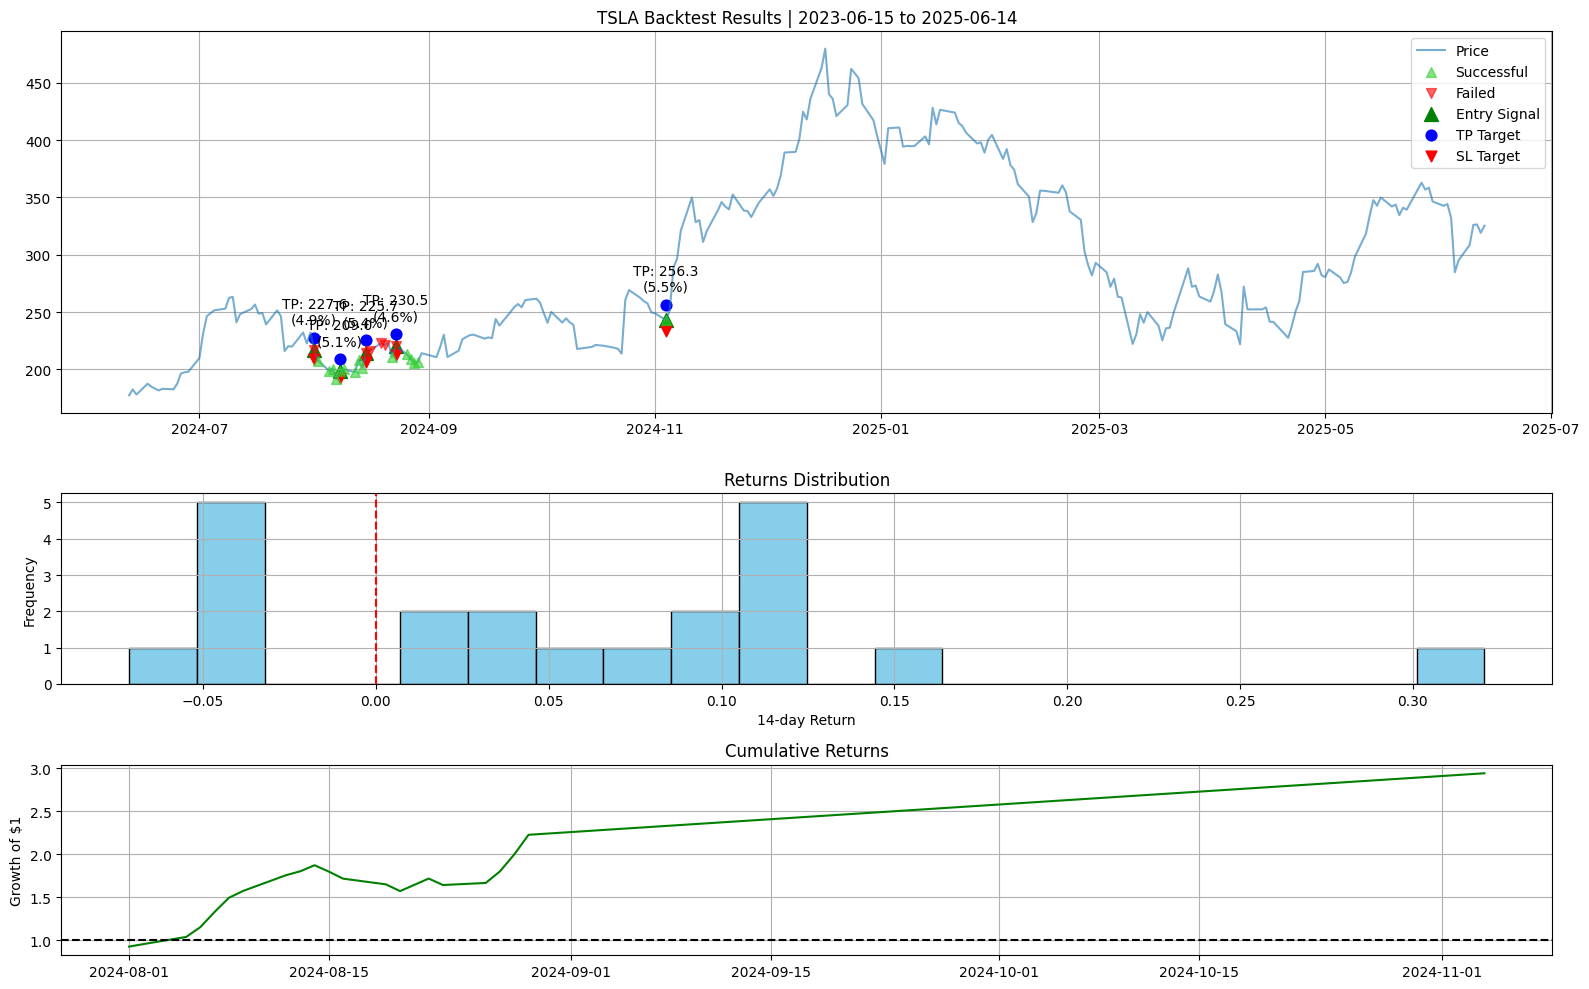

In [37]:
def train_and_backtest(ticker="COIN", train_years=2, show_every_n=20):
    # 1. Get and prepare data
    end_date = datetime.now()
    start_date = end_date - timedelta(days=365*train_years)
    df = get_stock_data(ticker, start_date, end_date)
    
    # Calculate all features
    df = add_technical_indicators(df)
    df = compute_expected_return(df)
    df = compute_expected_loss(df)
    df['5_day_return'] = df['Close'].pct_change(5)
    df['10_day_return'] = df['Close'].pct_change(10)
    df['Volatility'] = df['Close'].rolling(20).std()
    
    # Split into train/test (last year for testing)
    train_df = df.iloc[:-252] if len(df) > 252 else df
    test_df = df.iloc[-252:]
    
    # 2. Train models
    X_train = train_df[FEATURES]
    y_return = train_df['Expected_Return']
    y_loss = train_df['Expected_Loss']
    
    model_return = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
    model_loss = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
    model_return.fit(X_train, y_return)
    model_loss.fit(X_train, y_loss)
    
    # 3. Generate signals on test data
    signals = []
    for i in range(20, len(test_df)):  # Skip warmup period
        current = test_df.iloc[i:i+1]
        if current[FEATURES].isnull().values.any():
            continue
            
        current_price = current['Close'].values[0]
        date = current.index[0]
        
        # Predict
        pred_return = model_return.predict(current[FEATURES])[0]
        pred_loss = model_loss.predict(current[FEATURES])[0]
        
        # Calculate levels
        tp_price = current_price * (1 + pred_return)
        sl_price = current_price * (1 + pred_loss)
        optimal_entry = (current_price + sl_price) / 2
        
        # Future performance
        future_window = 9  # days
        if i + future_window < len(test_df):
            future_price = test_df.iloc[i+future_window]['Close']
            actual_return = (future_price - current_price) / current_price
        else:
            actual_return = np.nan
            
        signals.append({
            'Date': date,
            'Price': current_price,
            'TP': tp_price,
            'SL': sl_price,
            'Entry': optimal_entry,
            'Pred_Return': pred_return,
            'Actual_Return': actual_return,
            'Signal': current_price <= optimal_entry * 1.02
        })
    
    signals_df = pd.DataFrame(signals).set_index('Date')
    signals_df = signals_df[signals_df['Actual_Return'].notna()]

    
    # 4. Calculate Statistics
    trades = signals_df[signals_df['Signal']]
    if len(trades) == 0:
        print("No valid trades generated")
        return None

    # Separate successful and failed trades
    successful = trades[trades['Actual_Return'] > 0]
    failed = trades[trades['Actual_Return'] <= 0]
    
    stats = {
        'Total Trades': len(trades),
        'Total Wins': len(successful),
        'Total Failed': len(failed),
        'Win Rate': (trades['Actual_Return'] > 0).mean(),
        'Avg Return': trades['Actual_Return'].mean(),
        'Median Return': trades['Actual_Return'].median(),
        'Max Gain': trades['Actual_Return'].max(),
        'Max Loss': trades['Actual_Return'].min(),
        'Return/Risk': -trades['Actual_Return'].mean()/trades['Actual_Return'].min(),
        'Profit Factor': trades[trades['Actual_Return'] > 0]['Actual_Return'].sum() / 
                        -trades[trades['Actual_Return'] < 0]['Actual_Return'].sum()
    }
    
    # 5. Enhanced Visualization
    plt.figure(figsize=(16, 10))
    grid = plt.GridSpec(3, 1, height_ratios=[2, 1, 1])
    
    # Price Chart
    ax1 = plt.subplot(grid[0])
    plt.plot(test_df.index, test_df['Close'], label='Price', alpha=0.6)
   
    # Plot all signals but color-code them
    plt.scatter(successful.index, successful['Price'], color='limegreen', 
                marker='^', s=50, label='Successful', zorder=3, alpha=0.6)
    plt.scatter(failed.index, failed['Price'], color='red', 
                marker='v', s=50, label='Failed', zorder=3, alpha=0.6)
    
    # Plot signals
    sample = trades.iloc[::show_every_n]
    plt.scatter(sample.index, sample['Price'], color='green', 
                marker='^', s=100, label='Entry Signal')
    plt.scatter(sample.index, sample['TP'], color='blue', 
                marker='o', s=60, label='TP Target')
    plt.scatter(sample.index, sample['SL'], color='red', 
                marker='v', s=60, label='SL Target')
    
    # Annotations
    for date, row in sample.iterrows():
        plt.annotate(f"TP: {row['TP']:.1f}\n({row['Pred_Return']:.1%})",
                    (date, row['TP']), xytext=(0,10), 
                    textcoords='offset points', ha='center')
    
    plt.title(f"{ticker} Backtest Results | {start_date.date()} to {end_date.date()}")
    plt.legend()
    plt.grid(True)
    
    # Returns Distribution
    ax2 = plt.subplot(grid[1])
    plt.hist(trades['Actual_Return'], bins=20, color='skyblue', edgecolor='black')
    plt.axvline(x=0, color='red', linestyle='--')
    plt.title('Returns Distribution')
    plt.xlabel('14-day Return')
    plt.ylabel('Frequency')
    plt.grid(True)
    
    # Cumulative Returns
    ax3 = plt.subplot(grid[2])
    cumulative_returns = (1 + trades['Actual_Return']).cumprod()
    plt.plot(trades.index, cumulative_returns, label='Strategy', color='green')
    plt.axhline(y=1, color='black', linestyle='--')
    plt.title('Cumulative Returns')
    plt.ylabel('Growth of $1')
    plt.grid(True)
    
    plt.tight_layout()
    
    # Print Statistics
    print("\n=== Backtest Statistics ===")
    print(f"Period: {test_df.index[0].date()} to {test_df.index[-1].date()}")
    print(f"Total Trades: {stats['Total Trades']}")
    print(f"Wins#: {stats['Total Wins']:.2f}")
    print(f"Failures: {stats['Total Failed']:.2f}")
    print(f"Win Rate: {stats['Win Rate']:.1%}")
    print(f"Avg Return: {stats['Avg Return']:.2%}")
    print(f"Median Return: {stats['Median Return']:.2%}")
    print(f"Max Gain: {stats['Max Gain']:.2%}")
    print(f"Max Loss: {stats['Max Loss']:.2%}")
    print(f"Return/Risk Ratio: {stats['Return/Risk']:.2f}")
    print(f"Profit Factor: {stats['Profit Factor']:.2f}")
    
    return trades, stats

    
# Run backtest (showing every 15th signal)
trades, stats = train_and_backtest("TSLA", train_years=2, show_every_n=5)